In [53]:
import xgboost as xgb
import model_XGBoost as xgb_model

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from dateutil.relativedelta import relativedelta
import datetime as dt
import holidays
holidays_de= holidays.Germany()

from sklearn.metrics import mean_squared_error

plt.rcParams['figure.figsize'] = [12, 6]
plt.rcParams['figure.dpi'] = 100

In [54]:
df_all = pd.read_csv('../../data_cleaned/merged/02_4_clean_data.csv')
df_all.head()

,date,year,month,day,dayofyear,hour,week,dayofweek,price,period_start_utc,...,interpolated,dayofyear_sin1,dayofyear_cos1,hour_sin1,hour_cos1,dayofweek_sin1,dayofweek_cos1,is_holiday,day_type,price_gas
0,2019-01-01,2019,1,1,1,0,1,1,10.07,2019-01-01 00:00:00+00:00,...,0,0.0,1.0,0.000000,1.000000,0.781831,0.62349,1,holiday,22.28
1,2019-01-01,2019,1,1,1,1,1,1,-4.08,2019-01-01 01:00:00+00:00,...,0,0.0,1.0,0.258819,0.965926,0.781831,0.62349,1,holiday,22.28
2,2019-01-01,2019,1,1,1,2,1,1,-9.91,2019-01-01 02:00:00+00:00,...,0,0.0,1.0,0.500000,0.866025,0.781831,0.62349,1,holiday,22.28
3,2019-01-01,2019,1,1,1,3,1,1,-7.41,2019-01-01 03:00:00+00:00,...,0,0.0,1.0,0.707107,0.707107,0.781831,0.62349,1,holiday,22.28
4,2019-01-01,2019,1,1,1,4,1,1,-12.55,2019-01-01 04:00:00+00:00,...,0,0.0,1.0,0.866025,0.500000,0.781831,0.62349,1,holiday,22.28


In [55]:
df_years = df_all.query('2019 <= year').copy()
df_years.head()

,date,year,month,day,dayofyear,hour,week,dayofweek,price,period_start_utc,...,interpolated,dayofyear_sin1,dayofyear_cos1,hour_sin1,hour_cos1,dayofweek_sin1,dayofweek_cos1,is_holiday,day_type,price_gas
0,2019-01-01,2019,1,1,1,0,1,1,10.07,2019-01-01 00:00:00+00:00,...,0,0.0,1.0,0.000000,1.000000,0.781831,0.62349,1,holiday,22.28
1,2019-01-01,2019,1,1,1,1,1,1,-4.08,2019-01-01 01:00:00+00:00,...,0,0.0,1.0,0.258819,0.965926,0.781831,0.62349,1,holiday,22.28
2,2019-01-01,2019,1,1,1,2,1,1,-9.91,2019-01-01 02:00:00+00:00,...,0,0.0,1.0,0.500000,0.866025,0.781831,0.62349,1,holiday,22.28
3,2019-01-01,2019,1,1,1,3,1,1,-7.41,2019-01-01 03:00:00+00:00,...,0,0.0,1.0,0.707107,0.707107,0.781831,0.62349,1,holiday,22.28
4,2019-01-01,2019,1,1,1,4,1,1,-12.55,2019-01-01 04:00:00+00:00,...,0,0.0,1.0,0.866025,0.500000,0.781831,0.62349,1,holiday,22.28


In [56]:
df_years.drop(columns=['period_end_utc'], inplace=True)

In [57]:
df_years["period_start_utc"] = pd.to_datetime(df_years["period_start_utc"], errors="coerce")
df_years["period_start_utc"] = df_years["period_start_utc"].apply(lambda x: x.replace(tzinfo=None))
df_years["date"] = pd.to_datetime(df_years["date"], errors="coerce")

In [58]:
df_years.info()

<class 'pandas.core.frame.DataFrame'>
Index: 61367 entries, 0 to 61366
Data columns (total 34 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   date              61367 non-null  datetime64[ns]
 1   year              61367 non-null  int64         
 2   month             61367 non-null  int64         
 3   day               61367 non-null  int64         
 4   dayofyear         61367 non-null  int64         
 5   hour              61367 non-null  int64         
 6   week              61367 non-null  int64         
 7   dayofweek         61367 non-null  int64         
 8   price             61367 non-null  float64       
 9   period_start_utc  61367 non-null  datetime64[ns]
 10  c_by_hour         61367 non-null  int64         
 11  load_forecast_da  61367 non-null  float64       
 12  load_actual       61367 non-null  float64       
 13  off_wind_da       61367 non-null  float64       
 14  off_wind_act      61367 non

In [59]:
df_years.head()

,date,year,month,day,dayofyear,hour,week,dayofweek,price,period_start_utc,...,interpolated,dayofyear_sin1,dayofyear_cos1,hour_sin1,hour_cos1,dayofweek_sin1,dayofweek_cos1,is_holiday,day_type,price_gas
0,2019-01-01,2019,1,1,1,0,1,1,10.07,2019-01-01 00:00:00,...,0,0.0,1.0,0.000000,1.000000,0.781831,0.62349,1,holiday,22.28
1,2019-01-01,2019,1,1,1,1,1,1,-4.08,2019-01-01 01:00:00,...,0,0.0,1.0,0.258819,0.965926,0.781831,0.62349,1,holiday,22.28
2,2019-01-01,2019,1,1,1,2,1,1,-9.91,2019-01-01 02:00:00,...,0,0.0,1.0,0.500000,0.866025,0.781831,0.62349,1,holiday,22.28
3,2019-01-01,2019,1,1,1,3,1,1,-7.41,2019-01-01 03:00:00,...,0,0.0,1.0,0.707107,0.707107,0.781831,0.62349,1,holiday,22.28
4,2019-01-01,2019,1,1,1,4,1,1,-12.55,2019-01-01 04:00:00,...,0,0.0,1.0,0.866025,0.500000,0.781831,0.62349,1,holiday,22.28


In [60]:
df_years.set_index('period_start_utc', inplace=True)

In [61]:
df_years.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 61367 entries, 2019-01-01 00:00:00 to 2025-12-31 22:00:00
Data columns (total 33 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   date              61367 non-null  datetime64[ns]
 1   year              61367 non-null  int64         
 2   month             61367 non-null  int64         
 3   day               61367 non-null  int64         
 4   dayofyear         61367 non-null  int64         
 5   hour              61367 non-null  int64         
 6   week              61367 non-null  int64         
 7   dayofweek         61367 non-null  int64         
 8   price             61367 non-null  float64       
 9   c_by_hour         61367 non-null  int64         
 10  load_forecast_da  61367 non-null  float64       
 11  load_actual       61367 non-null  float64       
 12  off_wind_da       61367 non-null  float64       
 13  off_wind_act      61367 non-null  float64

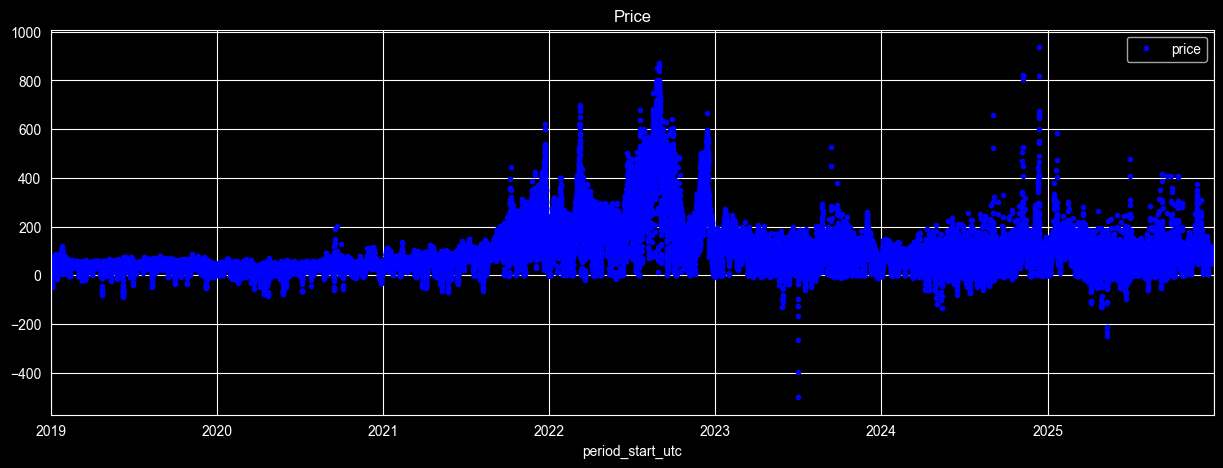

In [62]:
df_years.plot( y='price', style='.', figsize=(15, 5), color='blue', title='Price')
plt.show()

# Train / Test Split

In [63]:
start_date = pd.to_datetime('2019-01-01 00:00:00')
split_date = pd.to_datetime('2025-01-01 00:00:00')
end_date = pd.to_datetime('2026-01-01 00:00:00')

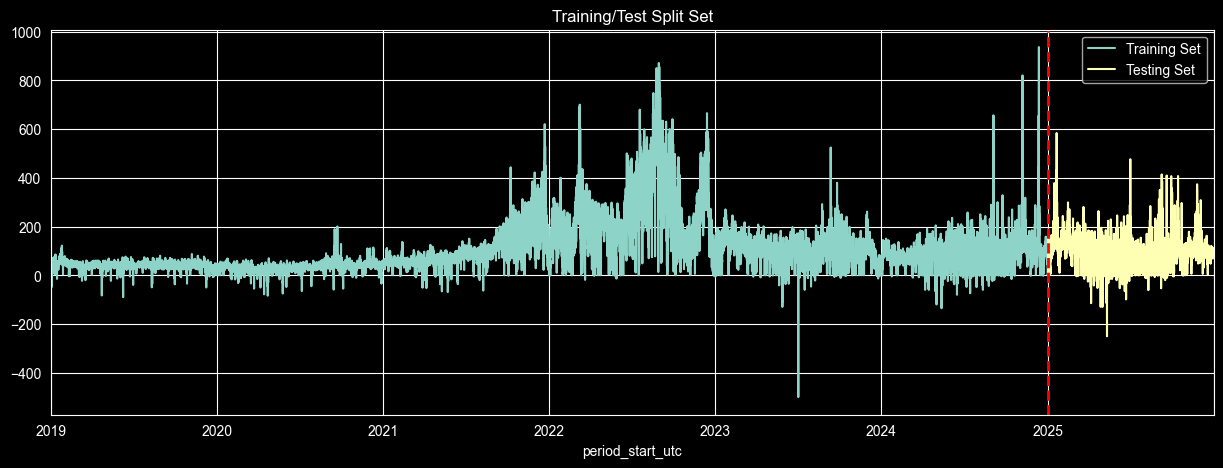

In [64]:
train = df_years.query('@start_date <= date < @split_date')
test = df_years.query('@split_date <= date < @end_date')

#train = df_years.query('date < 2021')
#test = df_years.query('2021 <= date < "2021-07"')

fig, ax = plt.subplots(figsize=(15, 5))
train.plot(y='price', ax=ax, label='Training Set', title='Training/Test Split Set')
test.plot(y='price', ax=ax, label = 'Testing Set')
ax.axvline(split_date, color='red', linestyle='dashed', linewidth=2)
plt.legend()
plt.show()

# Feature Creation

In [65]:
df_years.index

DatetimeIndex(['2019-01-01 00:00:00', '2019-01-01 01:00:00',
               '2019-01-01 02:00:00', '2019-01-01 03:00:00',
               '2019-01-01 04:00:00', '2019-01-01 05:00:00',
               '2019-01-01 06:00:00', '2019-01-01 07:00:00',
               '2019-01-01 08:00:00', '2019-01-01 09:00:00',
               ...
               '2025-12-31 13:00:00', '2025-12-31 14:00:00',
               '2025-12-31 15:00:00', '2025-12-31 16:00:00',
               '2025-12-31 17:00:00', '2025-12-31 18:00:00',
               '2025-12-31 19:00:00', '2025-12-31 20:00:00',
               '2025-12-31 21:00:00', '2025-12-31 22:00:00'],
              dtype='datetime64[ns]', name='period_start_utc', length=61367, freq=None)

In [66]:
def create_features(df):
    """
    create time series features based on time series index
    :param df:
    :return:
    """
    df = df.copy()

    df['hour'] = df.index.hour
    df['dayofweek'] = df.index.dayofweek
    df['weekday'] = df.index.weekday
    df['quarter'] = df.index.quarter
    df['month'] = df.index.month
    df['year'] = df.index.year
    df['dayofyear'] = df.index.dayofyear
    return df

Text(0.5, 1.0, 'Price by Hour')

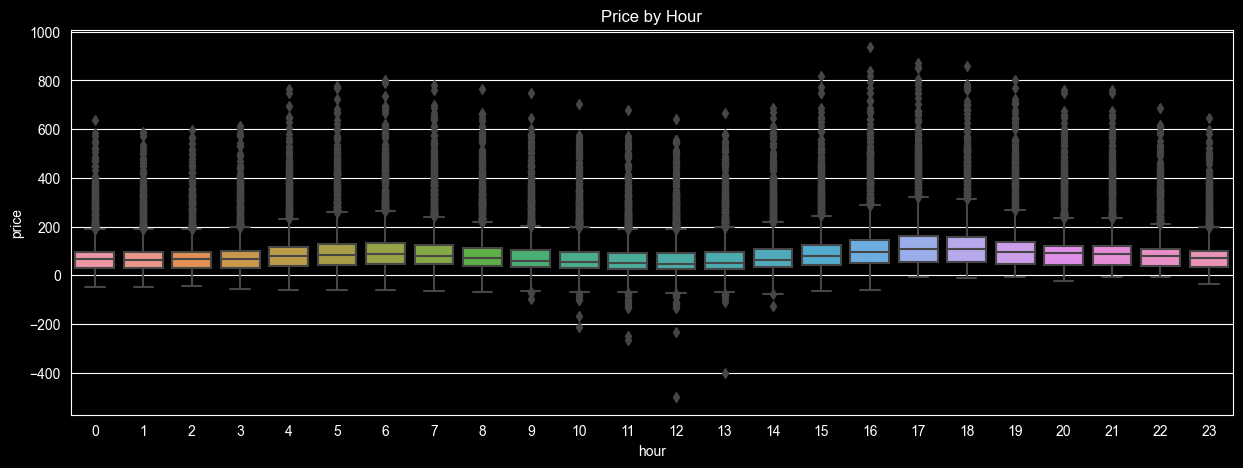

In [67]:
fig, ax = plt.subplots(figsize=(15, 5))
sns.boxplot(data = df_years, x = 'hour', y= 'price')
ax.set_title('Price by Hour')

Text(0.5, 1.0, 'Price by Month')

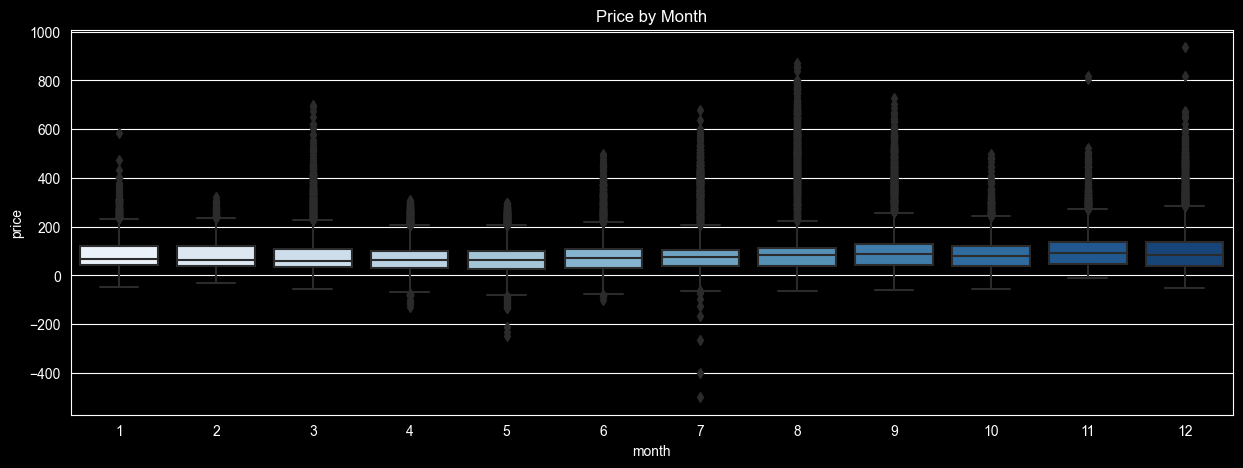

In [68]:
fig, ax = plt.subplots(figsize=(15, 5))
sns.boxplot(data = df_years, x = 'month', y= 'price', palette='Blues')
ax.set_title('Price by Month')

# Create Model

In [69]:
df_years.columns

Index(['date', 'year', 'month', 'day', 'dayofyear', 'hour', 'week',
       'dayofweek', 'price', 'c_by_hour', 'load_forecast_da', 'load_actual',
       'off_wind_da', 'off_wind_act', 'on_wind_da', 'on_wind_act', 'solar_da',
       'solar_act', 'gen_forecast_da', 'gen_actual', 'res_sum_da',
       'res_sum_act', 'imputed', 'interpolated', 'dayofyear_sin1',
       'dayofyear_cos1', 'hour_sin1', 'hour_cos1', 'dayofweek_sin1',
       'dayofweek_cos1', 'is_holiday', 'day_type', 'price_gas'],
      dtype='object')

In [70]:
FEATURES = ['year', 'month', 'day', 'dayofyear', 'hour', 'week', 'dayofweek', 'load_forecast_da', 'res_sum_da']
TARGET = 'price'

In [71]:
reg = xgb_model.create_and_train_XGBoost(train, test, FEATURES, TARGET)

[0]	validation_0-rmse:136.78550	validation_1-rmse:102.47607
[50]	validation_0-rmse:94.88557	validation_1-rmse:68.55315
[100]	validation_0-rmse:70.69159	validation_1-rmse:48.92365
[150]	validation_0-rmse:54.83166	validation_1-rmse:38.89203
[200]	validation_0-rmse:44.68288	validation_1-rmse:34.00311
[250]	validation_0-rmse:38.61407	validation_1-rmse:31.60347
[300]	validation_0-rmse:34.05042	validation_1-rmse:30.43946
[350]	validation_0-rmse:31.07018	validation_1-rmse:29.72652
[400]	validation_0-rmse:29.38855	validation_1-rmse:29.26344
[450]	validation_0-rmse:27.98309	validation_1-rmse:29.09105
[500]	validation_0-rmse:26.92607	validation_1-rmse:29.07615
[550]	validation_0-rmse:26.02649	validation_1-rmse:29.20527
[600]	validation_0-rmse:25.19719	validation_1-rmse:29.40383
[650]	validation_0-rmse:24.42828	validation_1-rmse:29.59225
[700]	validation_0-rmse:23.69335	validation_1-rmse:29.89700
[750]	validation_0-rmse:23.03952	validation_1-rmse:30.09406
[800]	validation_0-rmse:22.58019	validati

# Feature Importance

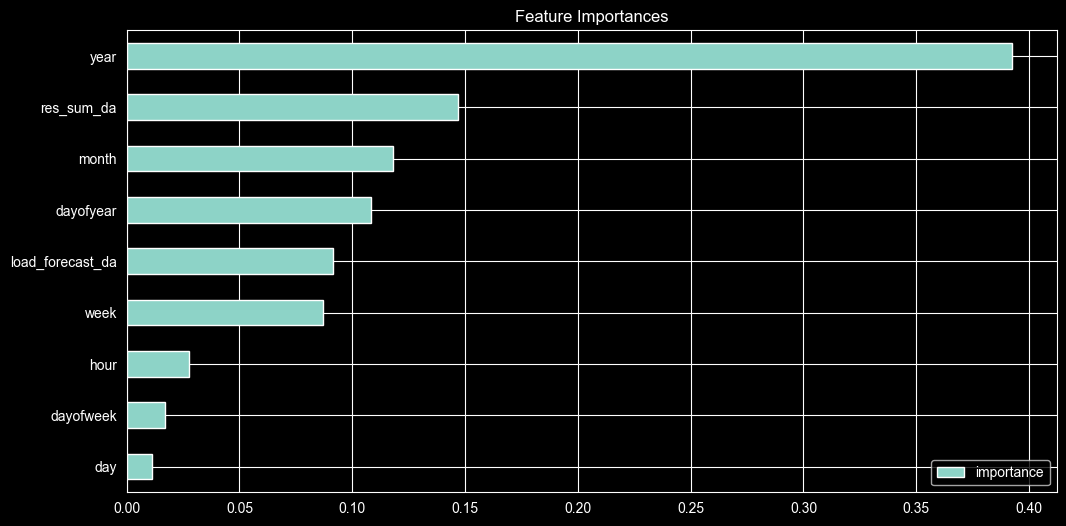

In [72]:
xgb_model.display_feature_importance(reg)

# Forecast on Test

In [73]:
test['prediction'] = reg.predict(test[FEATURES])
test

C:\Users\bened\AppData\Local\Temp\ipykernel_10604\3475154307.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  test['prediction'] = reg.predict(test[FEATURES])


,date,year,month,day,dayofyear,hour,week,dayofweek,price,c_by_hour,...,dayofyear_sin1,dayofyear_cos1,hour_sin1,hour_cos1,dayofweek_sin1,dayofweek_cos1,is_holiday,day_type,price_gas,prediction
period_start_utc,,,,,,,,,,,,,,,,,,,,,
2025-01-01 00:00:00,2025-01-01,2025,1,1,1,0,1,2,1.6000,4,...,0.000000,1.000000,0.000000,1.000000e+00,0.974928,-0.222521,1,holiday,48.889,6.915274
2025-01-01 01:00:00,2025-01-01,2025,1,1,1,1,1,2,0.0000,4,...,0.000000,1.000000,0.258819,9.659258e-01,0.974928,-0.222521,1,holiday,48.889,6.929460
2025-01-01 02:00:00,2025-01-01,2025,1,1,1,2,1,2,-0.0100,4,...,0.000000,1.000000,0.500000,8.660254e-01,0.974928,-0.222521,1,holiday,48.889,6.677138
2025-01-01 03:00:00,2025-01-01,2025,1,1,1,3,1,2,-0.0100,4,...,0.000000,1.000000,0.707107,7.071068e-01,0.974928,-0.222521,1,holiday,48.889,6.616389
2025-01-01 04:00:00,2025-01-01,2025,1,1,1,4,1,2,-0.0600,4,...,0.000000,1.000000,0.866025,5.000000e-01,0.974928,-0.222521,1,holiday,48.889,6.929460
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2025-12-31 18:00:00,2025-12-31,2025,12,31,365,18,1,2,95.9900,4,...,-0.021501,0.999769,-1.000000,-1.836970e-16,0.974928,-0.222521,0,weekday,27.755,99.283600
2025-12-31 19:00:00,2025-12-31,2025,12,31,365,19,1,2,86.8025,4,...,-0.021501,0.999769,-0.965926,2.588190e-01,0.974928,-0.222521,0,weekday,27.755,88.634605
2025-12-31 20:00:00,2025-12-31,2025,12,31,365,20,1,2,79.7975,4,...,-0.021501,0.999769,-0.866025,5.000000e-01,0.974928,-0.222521,0,weekday,27.755,82.636406


In [74]:
df_years = df_years.merge(test[['prediction']],  how = 'left', left_index=True, right_index=True) # merge on index columns

In [75]:
df_years

,date,year,month,day,dayofyear,hour,week,dayofweek,price,c_by_hour,...,dayofyear_sin1,dayofyear_cos1,hour_sin1,hour_cos1,dayofweek_sin1,dayofweek_cos1,is_holiday,day_type,price_gas,prediction
period_start_utc,,,,,,,,,,,,,,,,,,,,,
2019-01-01 00:00:00,2019-01-01,2019,1,1,1,0,1,1,10.0700,4,...,0.000000,1.000000,0.000000,1.000000e+00,0.781831,0.623490,1,holiday,22.280,NaN
2019-01-01 01:00:00,2019-01-01,2019,1,1,1,1,1,1,-4.0800,4,...,0.000000,1.000000,0.258819,9.659258e-01,0.781831,0.623490,1,holiday,22.280,NaN
2019-01-01 02:00:00,2019-01-01,2019,1,1,1,2,1,1,-9.9100,4,...,0.000000,1.000000,0.500000,8.660254e-01,0.781831,0.623490,1,holiday,22.280,NaN
2019-01-01 03:00:00,2019-01-01,2019,1,1,1,3,1,1,-7.4100,4,...,0.000000,1.000000,0.707107,7.071068e-01,0.781831,0.623490,1,holiday,22.280,NaN
2019-01-01 04:00:00,2019-01-01,2019,1,1,1,4,1,1,-12.5500,4,...,0.000000,1.000000,0.866025,5.000000e-01,0.781831,0.623490,1,holiday,22.280,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2025-12-31 18:00:00,2025-12-31,2025,12,31,365,18,1,2,95.9900,4,...,-0.021501,0.999769,-1.000000,-1.836970e-16,0.974928,-0.222521,0,weekday,27.755,99.283600
2025-12-31 19:00:00,2025-12-31,2025,12,31,365,19,1,2,86.8025,4,...,-0.021501,0.999769,-0.965926,2.588190e-01,0.974928,-0.222521,0,weekday,27.755,88.634605
2025-12-31 20:00:00,2025-12-31,2025,12,31,365,20,1,2,79.7975,4,...,-0.021501,0.999769,-0.866025,5.000000e-01,0.974928,-0.222521,0,weekday,27.755,82.636406


In [76]:
df_years.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 61367 entries, 2019-01-01 00:00:00 to 2025-12-31 22:00:00
Data columns (total 34 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   date              61367 non-null  datetime64[ns]
 1   year              61367 non-null  int64         
 2   month             61367 non-null  int64         
 3   day               61367 non-null  int64         
 4   dayofyear         61367 non-null  int64         
 5   hour              61367 non-null  int64         
 6   week              61367 non-null  int64         
 7   dayofweek         61367 non-null  int64         
 8   price             61367 non-null  float64       
 9   c_by_hour         61367 non-null  int64         
 10  load_forecast_da  61367 non-null  float64       
 11  load_actual       61367 non-null  float64       
 12  off_wind_da       61367 non-null  float64       
 13  off_wind_act      61367 non-null  float64

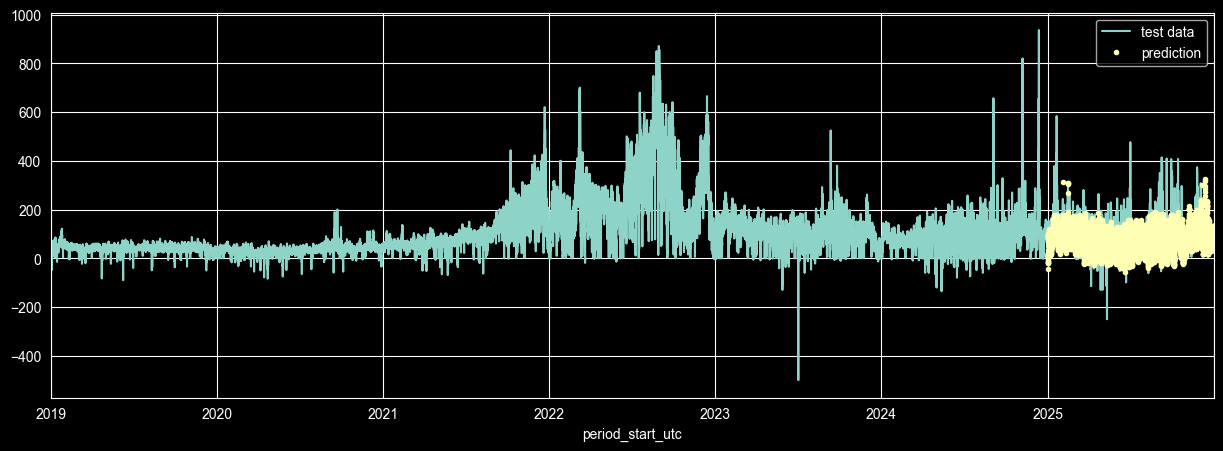

Text(0.5, 1.0, 'Test Data and Predictions')

In [77]:
ax = df_years[['price']].plot(figsize=(15, 5))
df_years['prediction'].plot(ax=ax, style = '.')
plt.legend(['test data', 'prediction'])
plt.show()
ax.set_title('Test Data and Predictions')

# smaller test frames

In [78]:
add_three_months = relativedelta(months=3)
add_one_week = relativedelta(days=7)

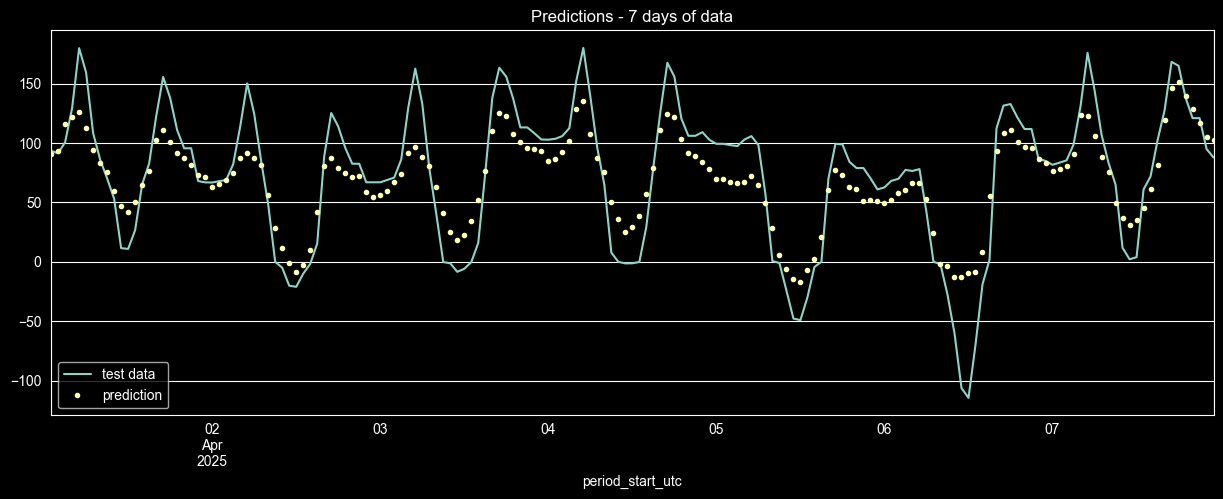

In [79]:
first_day_four_months_in = split_date + add_three_months
first_day_four_months_in.to_datetime64()
last_day_four_months_in = first_day_four_months_in + add_one_week
last_day_four_months_in.to_datetime64()

ax = df_years.loc[(first_day_four_months_in < df_years.index) & (df_years.index < last_day_four_months_in)]['price'].plot(figsize=(15, 5), title='Predictions - 7 days of data')
df_years.loc[(first_day_four_months_in < df_years.index) & (df_years.index < last_day_four_months_in)]['prediction'].plot(ax=ax, style='.')
plt.legend(['test data', 'prediction'])
plt.show()

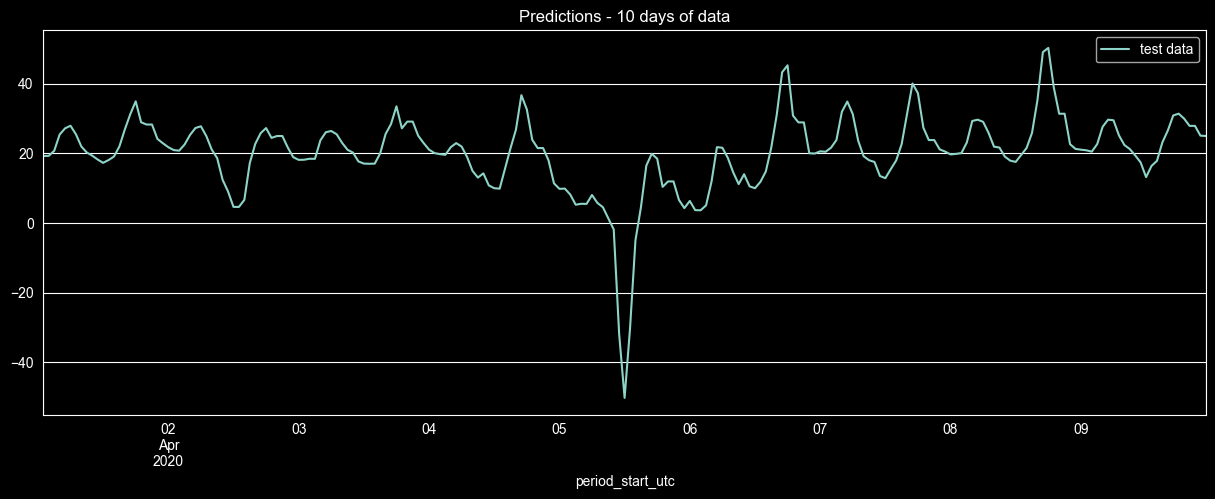

In [80]:
ax = df_years.loc[("2020-04-01" < df_years.index) & (df_years.index < "2020-04-10")]['price'].plot(figsize=(15, 5), title='Predictions - 10 days of data')
plt.legend(['test data'])
plt.show()

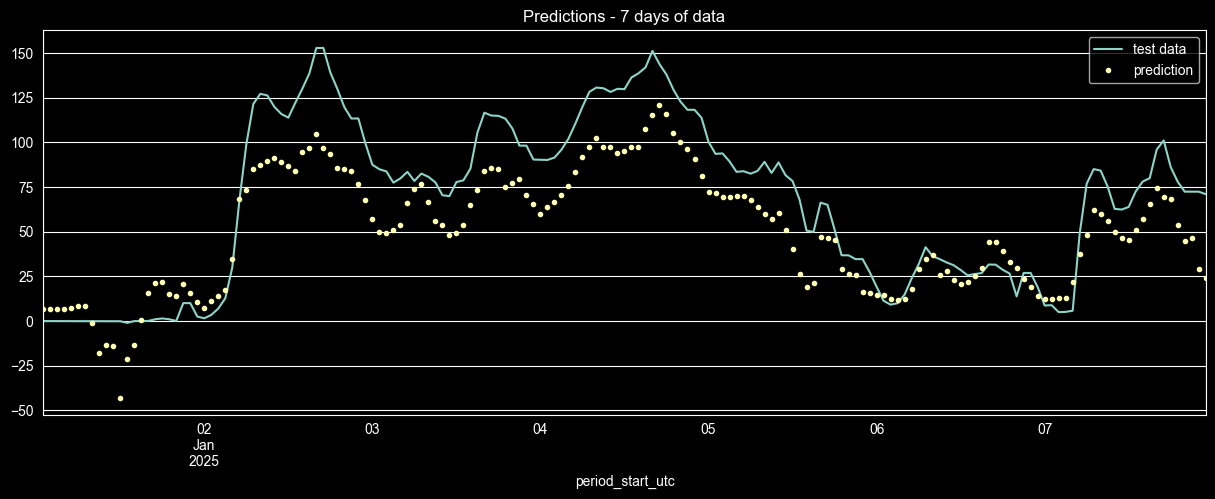

In [81]:
split_date_one_week_in = split_date + add_one_week

ax = df_years.loc[(split_date < df_years.index) & (df_years.index < split_date_one_week_in)]['price'].plot(figsize=(15, 5), title='Predictions - 7 days of data')
df_years.loc[(split_date < df_years.index) & (df_years.index < split_date_one_week_in)]['prediction'].plot(ax=ax, style='.')
plt.legend(['test data', 'prediction'])
plt.show()